## Basic Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras.layers import BatchNormalization
from keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [2]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [3]:
model_name = '2_finetuned_real_eyes'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [4]:
comment = "experimental run 2"
model_file_path = repo_path + f"/models/cnn/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/history/{comment}_history.csv"
# assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [5]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 100
FT_LEARNING_RATE_1 = 0.0001
OPTIMIZER_1 = SGD(learning_rate=FT_LEARNING_RATE_1)
FT_LEARNING_RATE_2 = 0.00001
OPTIMIZER_2 = SGD(learning_rate=FT_LEARNING_RATE_2)

In [6]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [36]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

labels = ['Closed', 'Open']

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [8]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/1_synthetic_eyes/1_full_network/weights/evening run_model.keras'

Test accuracy: 0.47
Test precision: 0.487
Test recall: 0.781
Test F1 score: 0.6


2024-07-16 12:35:26.370552: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


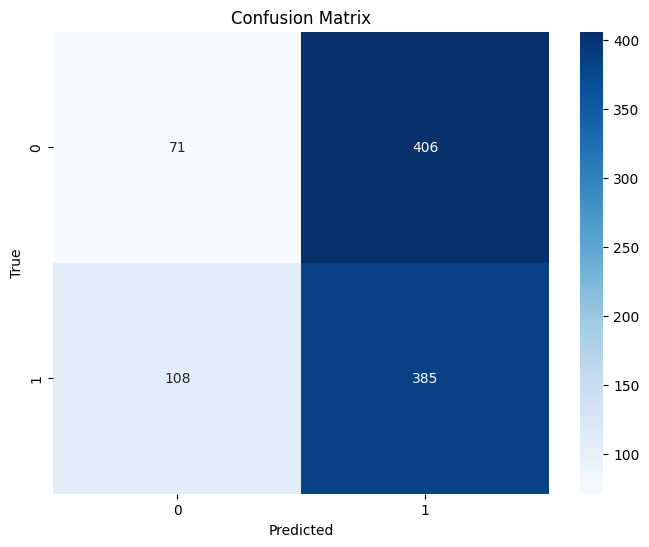

In [9]:
# load the model with compiling
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, real_test_data)

In [10]:
# load and override the model again without compiling it
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers after block_16_project_BN
unfreeze = False
for layer in model.layers:
    layer.trainable = False
    if unfreeze and not isinstance(layer, BatchNormalization):
        layer.trainable = True
    if layer.name == 'block_16_project_BN':
        unfreeze = True

# display the summary if needed
model.summary(show_trainable=True)

Model: "1_pretrain_cnn"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ input_layer_2… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 5,892,290 (22.48 MB)

 Trainable params: 4,047,490 (15.44 MB)

 Non-trainable params: 1,844,800 (7.04 MB)

In [11]:
# STEP 1

# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER_1, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=50,
    callbacks=[checkpoint] # early_stop, reduce_lr
    )

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.5782 - loss: 7.9863
Epoch 1: val_accuracy improved from -inf to 0.79613, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/2_finetuned_real_eyes/ckpt/experimental run 2_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 813ms/step - accuracy: 0.5790 - loss: 7.9809 - val_accuracy: 0.7961 - val_loss: 7.0826
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7267 - loss: 7.3406
Epoch 2: val_accuracy improved from 0.79613 to 0.85935, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/2_finetuned_real_eyes/ckpt/experimental run 2_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 720ms/step - accuracy: 0.7269 - loss: 7.3396 - val_accuracy: 0.8594 - val_loss: 6.9856
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7754 - loss: 7.2085
Epoch 3: val_accuracy improved from 0.85935 to 0.89419, s

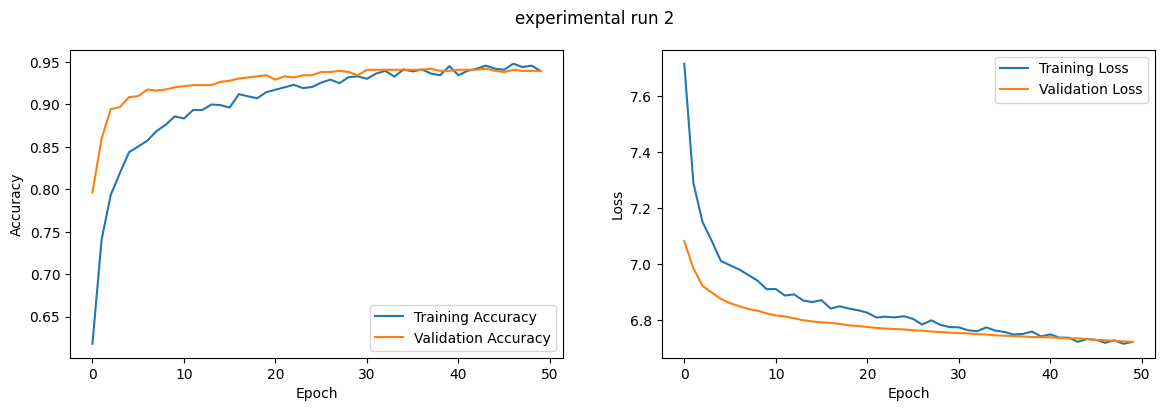

Best train_accuracy: 0.9478
Best train_loss: 6.7167
Best val_accuracy: 0.9419
Best val_loss: 6.7233
Last improvement at epoch: 38
Test accuracy: 0.942
Test precision: 0.938
Test recall: 0.949
Test F1 score: 0.944


2024-07-16 13:05:30.054659: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


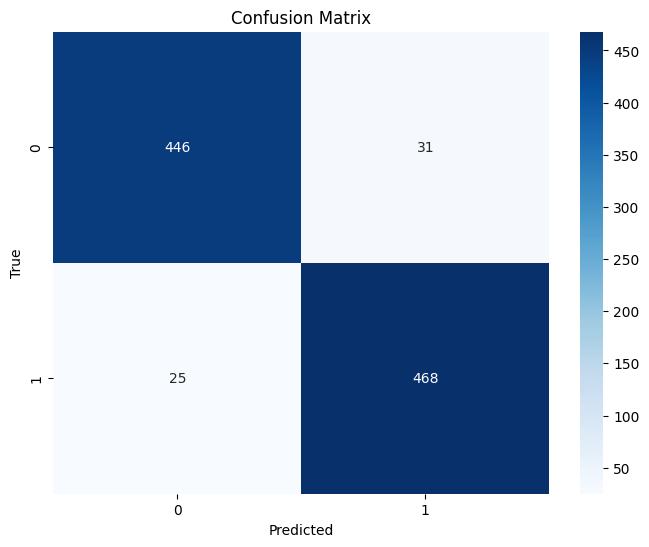

In [12]:
plot_history(comment=comment, history=history)
model.load_weights(ckpt_file_path)
model.save(model_file_path)
evaluate_model(model, real_test_data)

In [13]:
# unfreeze all layers which are not BN layers
for layer in model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

# display the summary if needed
model.summary(show_trainable=True)

Model: "1_pretrain_cnn"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ input_layer_2… │   Y   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   Y   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   Y   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   Y   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   Y   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   Y 

 Total params: 5,892,292 (22.48 MB)

 Trainable params: 5,827,650 (22.23 MB)

 Non-trainable params: 64,640 (252.50 KB)

 Optimizer params: 2 (12.00 B)

In [14]:
# STEP 2

# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER_2, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=50,
    callbacks=[checkpoint] # early_stop, reduce_lr
    )

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9324 - loss: 6.7557
Epoch 1: val_accuracy did not improve from 0.94194
49/49 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9324 - loss: 6.7558 - val_accuracy: 0.9329 - val_loss: 6.7492
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9375 - loss: 6.7613
Epoch 2: val_accuracy did not improve from 0.94194
49/49 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9376 - loss: 6.7611 - val_accuracy: 0.9406 - val_loss: 6.7512
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9393 - loss: 6.7459
Epoch 3: val_accuracy improved from 0.94194 to 0.94452, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/2_finetuned_real_eyes/ckpt/experimental run 2_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9394 - loss: 6.7459 - val_accuracy: 0.9445 - val_loss: 6.7362
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9454 - loss: 6

In [15]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [16]:
# load the best model
model.load_weights(ckpt_file_path)

In [17]:
# save the model
model.save(model_file_path)

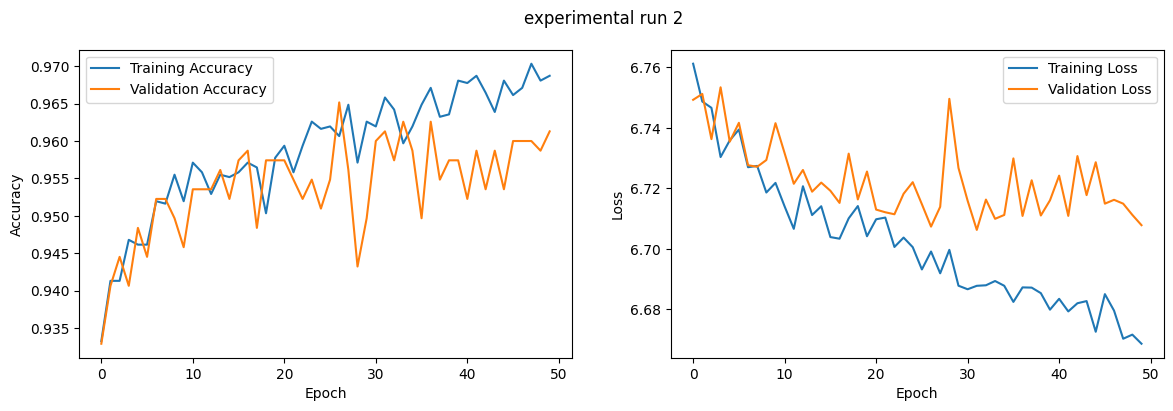

Best train_accuracy: 0.9703
Best train_loss: 6.6686
Best val_accuracy: 0.9652
Best val_loss: 6.7063
Last improvement at epoch: 27


In [18]:
plot_history(comment=comment, history=history)

Test accuracy: 0.959
Test precision: 0.963
Test recall: 0.955
Test F1 score: 0.959


2024-07-16 14:34:19.771464: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


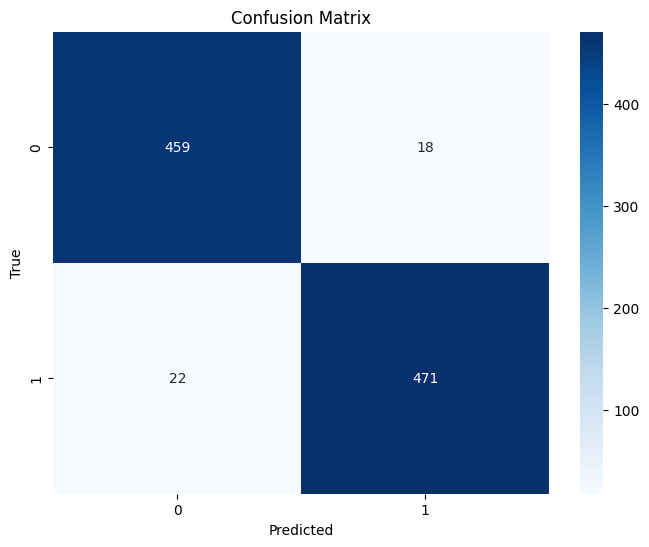

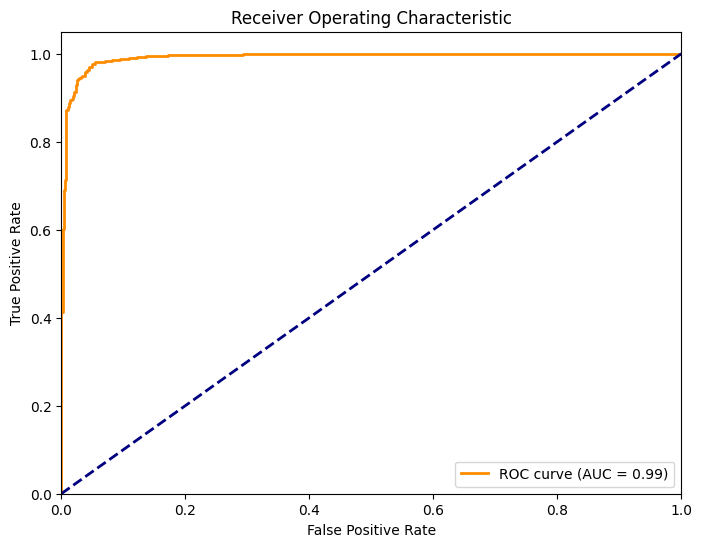

In [21]:
evaluate_model(model, real_test_data, labels=labels)

In [37]:
labels

['Closed', 'Open']

2024-07-16 15:18:07.609178: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


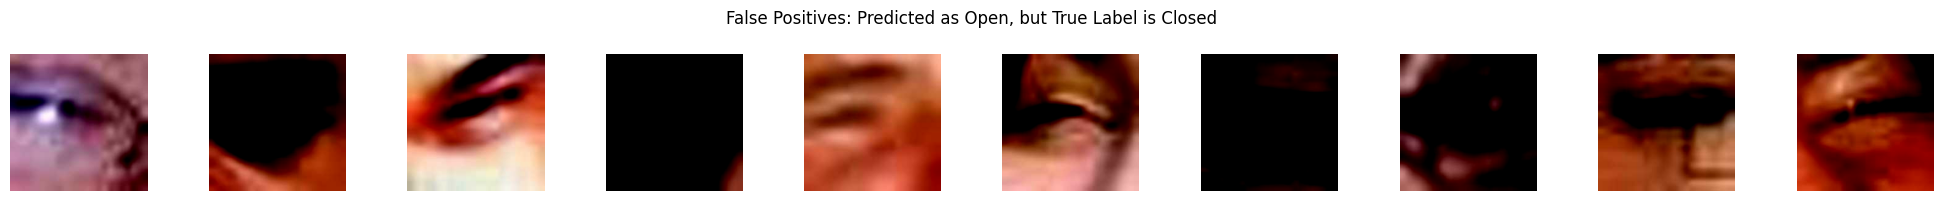

2024-07-16 15:18:16.081645: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


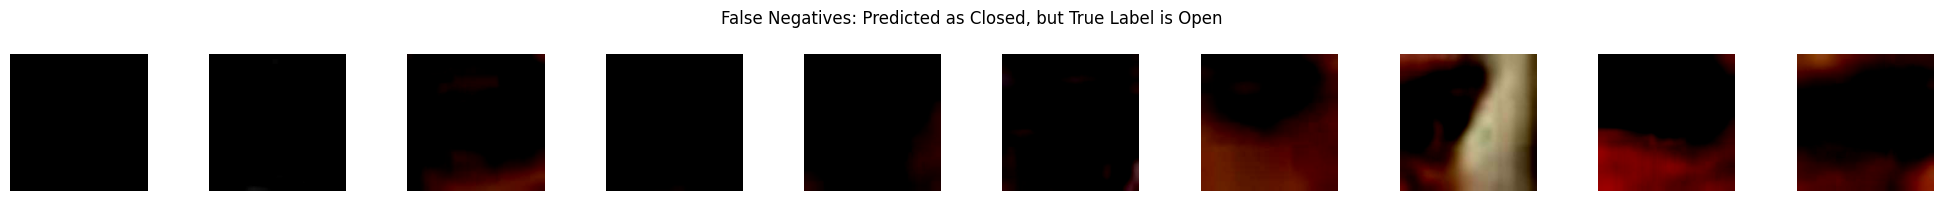

In [42]:
plot_false_positives(model, real_test_data, n=10, labels=labels)
plot_false_negatives(model, real_test_data, n=10, labels=labels)